<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/regularization_regression_kr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 정규화 회귀 (Ridge, Lasso 비교) 실습

이 노트북에서는 선형 회귀 모델에서 과적합을 방지하기 위한 정규화 기법인 Ridge 회귀와 Lasso 회귀를 비교해보겠습니다. 두 방법 모두 모델의 복잡성을 제한하여 일반화 성능을 향상시키는 것을 목표로 합니다.

## 1. 필요한 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

# 한글 폰트 설정 (필요한 경우)
import matplotlib.font_manager as fm
import matplotlib as mpl

# 시각화를 위한 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 랜덤 시드 설정
np.random.seed(42)

## 2. 데이터 생성

먼저 회귀 분석을 위한 인공 데이터셋을 생성합니다. 이 데이터셋은 다중 공선성(multicollinearity)이 있는 특성을 포함하여 정규화의 효과를 잘 보여줄 수 있도록 설계되었습니다.

In [2]:
# 인공 데이터셋 생성
X, y = make_regression(n_samples=200, n_features=20, n_informative=10,
                       noise=20, random_state=42)

# 다중 공선성을 추가하기 위해 일부 특성을 다른 특성의 선형 조합으로 만듦
X[:, 5] = X[:, 1] * 0.8 + X[:, 2] * 0.2 + np.random.normal(0, 0.1, X.shape[0])
X[:, 15] = X[:, 10] * 0.7 + X[:, 8] * 0.3 + np.random.normal(0, 0.1, X.shape[0])

# 데이터 확인
print(f"데이터 형태: {X.shape}, 타겟 형태: {y.shape}")

# 데이터프레임으로 변환
df = pd.DataFrame(X, columns=[f'특성_{i}' for i in range(X.shape[1])])
df['타겟'] = y

# 데이터 미리보기
df.head()

데이터 형태: (200, 20), 타겟 형태: (200,)


,특성_0,특성_1,특성_2,특성_3,특성_4,특성_5,특성_6,특성_7,특성_8,특성_9,...,특성_11,특성_12,특성_13,특성_14,특성_15,특성_16,특성_17,특성_18,특성_19,타겟
0,0.198085,-0.144360,0.059218,-0.272724,-0.335785,-0.053973,0.013929,-1.503143,-0.245743,-0.054295,...,1.126565,-1.106526,-0.259591,-2.696887,0.449400,2.573360,1.848956,1.669022,-0.268889,-249.654438
1,-0.968046,-0.310308,-0.397558,1.171718,-0.399899,-0.341584,1.237654,0.182501,-0.670115,0.487560,...,-0.528297,-1.422975,-0.044893,-1.176173,0.191680,-0.970124,-0.202524,0.269295,1.036088,-36.004789
2,-0.388177,0.170416,-0.337086,-1.975467,0.056650,0.133685,-0.613403,0.486502,0.064474,-0.144088,...,1.218762,1.490726,-0.070499,-0.939335,0.547598,0.148667,1.530751,0.529693,-0.213443,-80.374940
3,0.513908,0.179582,1.938929,1.187679,0.403730,0.683754,-1.000331,0.324359,-1.179040,0.201160,...,-0.474904,-1.345980,-0.903702,-0.464617,-0.429565,0.126380,0.586694,-0.024196,0.871297,-112.745566
4,-0.552223,0.632932,-0.570746,0.492451,-0.049464,0.368781,-0.832356,0.382410,0.166452,2.455300,...,-0.555477,1.189017,-1.122722,0.289169,-0.459529,1.420504,-0.623141,0.674819,-0.637387,30.043768


## 3. 데이터 탐색 및 전처리

In [3]:
# 데이터 기본 통계 확인
df.describe()

,특성_0,특성_1,특성_2,특성_3,특성_4,특성_5,특성_6,특성_7,특성_8,특성_9,...,특성_11,특성_12,특성_13,특성_14,특성_15,특성_16,특성_17,특성_18,특성_19,타겟
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.095857,0.078436,0.060024,-0.023906,0.118107,0.070677,0.002095,-0.039981,-0.041669,0.049606,...,0.002344,-0.001875,-0.037622,-0.095751,0.083394,0.071443,-0.075203,0.070502,0.040172,-5.157718
std,0.961353,0.909686,1.079111,1.014562,0.947236,0.764654,0.981475,0.976775,1.009479,0.961080,...,1.100523,0.995014,1.061102,1.023642,0.775549,1.060126,0.910546,1.042968,0.990543,157.937438
min,-2.604214,-2.872262,-2.591042,-2.532246,-2.499406,-2.620333,-2.635748,-2.390304,-3.019512,-2.991136,...,-2.940389,-2.198806,-3.241267,-2.696887,-1.799193,-2.929449,-2.703232,-2.896255,-2.906988,-471.596529
25%,-0.552580,-0.435979,-0.583048,-0.804024,-0.560505,-0.414814,-0.670177,-0.824742,-0.679842,-0.696975,...,-0.750615,-0.771787,-0.705359,-0.812197,-0.402404,-0.653336,-0.623746,-0.580119,-0.646181,-92.805519
50%,0.129911,0.089929,0.037928,0.043514,0.176456,0.105326,-0.019075,-0.045594,-0.058241,0.030920,...,-0.031868,0.024420,-0.028554,-0.064299,0.063128,-0.018862,-0.067140,0.016539,0.048915,-4.619684
75%,0.729682,0.638837,0.731732,0.668974,0.700248,0.579228,0.648027,0.698653,0.627523,0.689014,...,0.755647,0.710613,0.634013,0.557876,0.610102,0.829423,0.588410,0.745732,0.633819,105.566923
max,3.078881,2.720169,3.926238,3.109919,2.526932,2.367560,3.243093,2.270693,2.426716,2.455300,...,2.558199,2.601683,3.152057,2.949094,2.334990,2.644343,1.848956,2.985259,2.303639,373.915249


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
<ipython-input-4-4644d35ecd30>:6: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-4-4644d35ecd30>:6: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-4-4644d35ecd

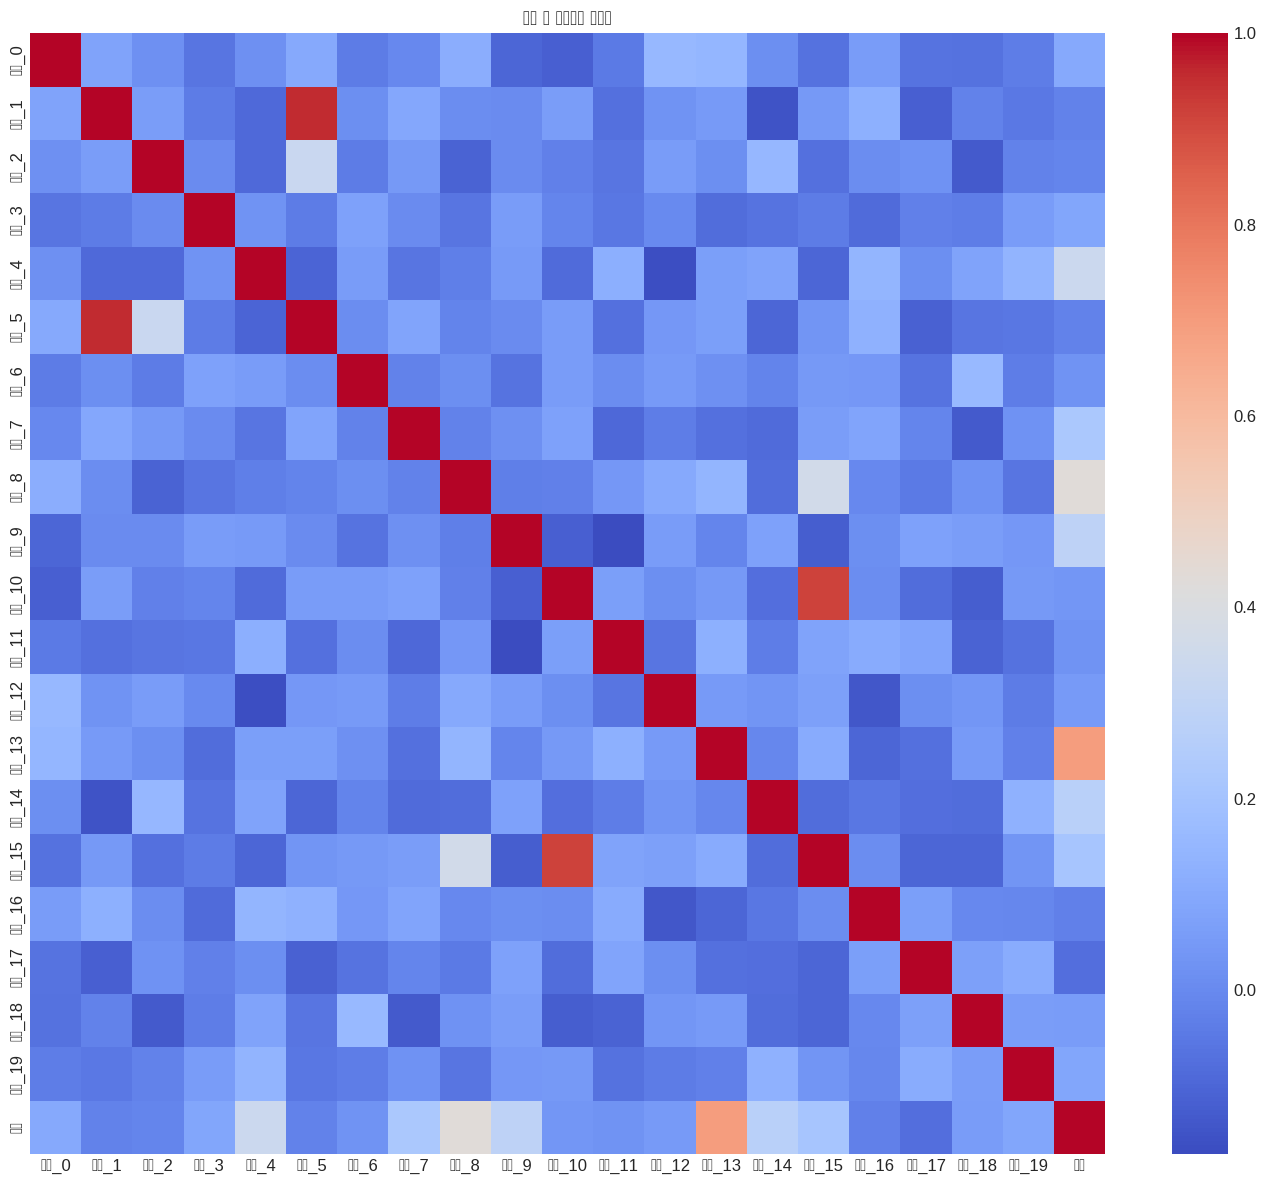

In [4]:
# 특성 간 상관관계 확인
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('특성 간 상관관계 히트맵')
plt.tight_layout()
plt.show()

<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-5-c4e00e964411>:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Liberation Sans.
  plt

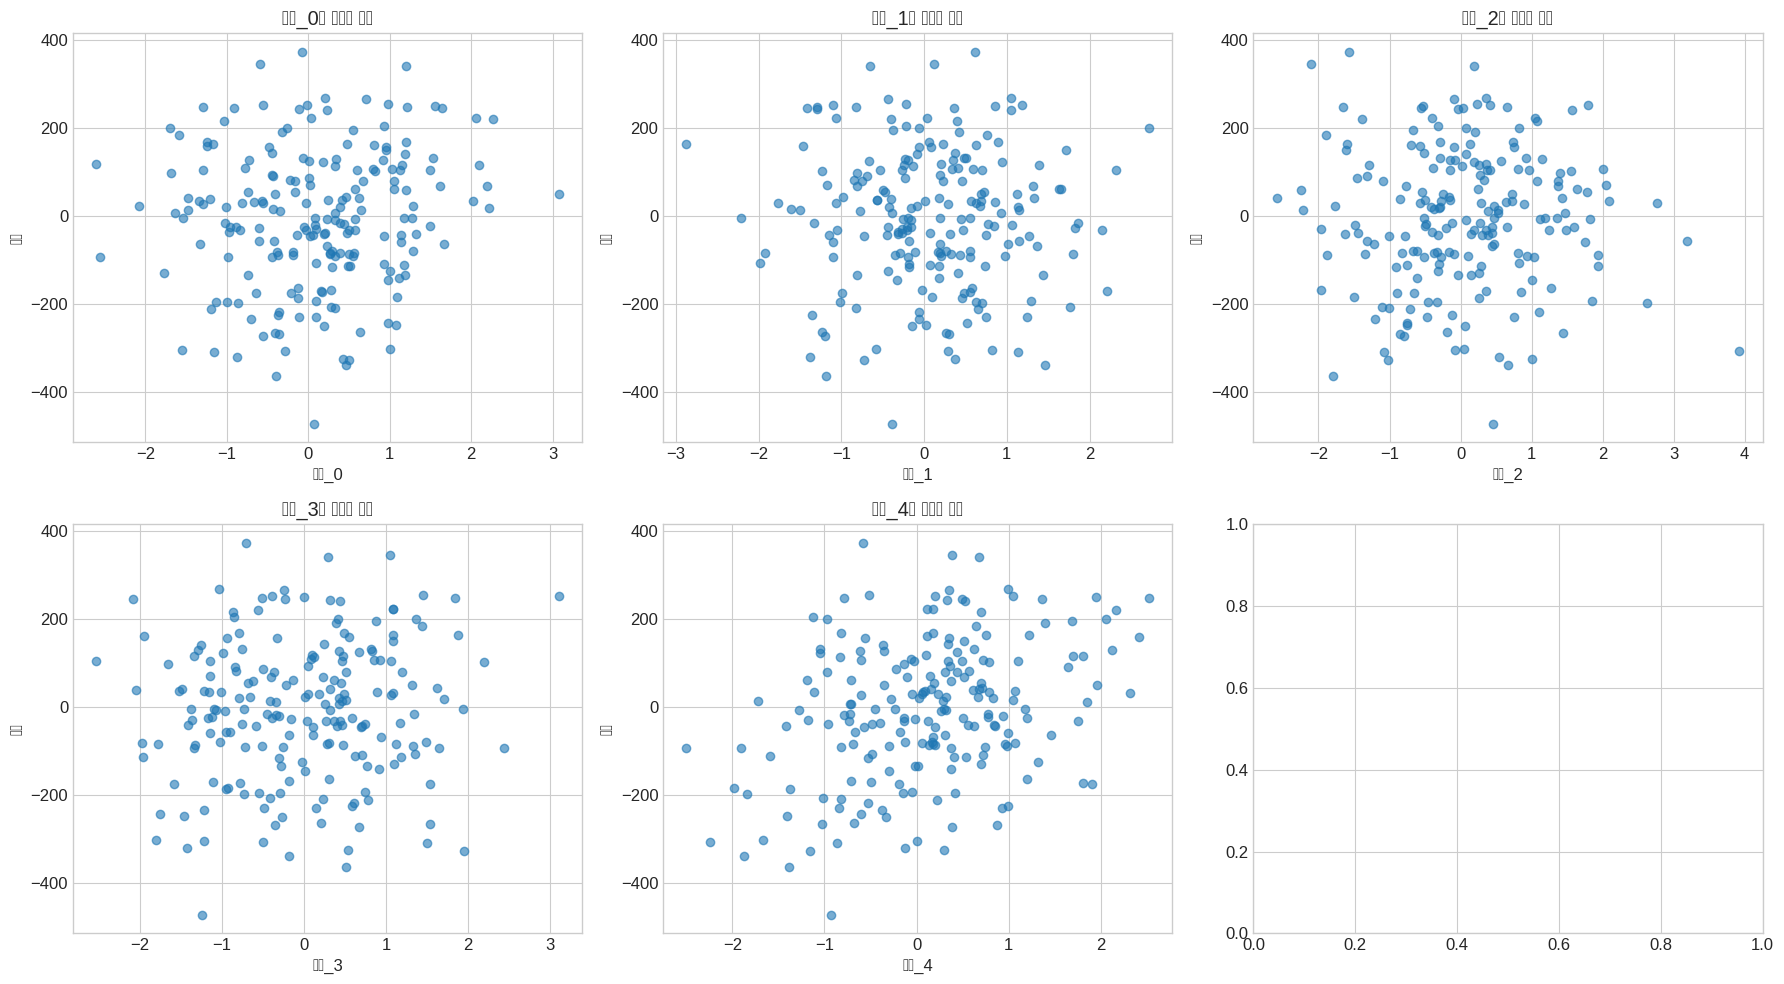

In [5]:
# 특성과 타겟 간의 관계 시각화 (처음 5개 특성만)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:5]):
    ax.scatter(df[f'특성_{i}'], df['타겟'], alpha=0.6)
    ax.set_xlabel(f'특성_{i}')
    ax.set_ylabel('타겟')
    ax.set_title(f'특성_{i}와 타겟의 관계')

plt.tight_layout()
plt.show()

In [6]:
# 훈련/테스트 데이터 분할
X = df.drop('타겟', axis=1)
y = df['타겟']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"훈련 데이터 크기: {X_train.shape}, 테스트 데이터 크기: {X_test.shape}")

훈련 데이터 크기: (160, 20), 테스트 데이터 크기: (40, 20)


In [7]:
# 특성 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일링 결과 확인
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("스케일링 후 데이터 통계:")
X_train_scaled_df.describe().loc[['mean', 'std']].round(2)

스케일링 후 데이터 통계:


,특성_0,특성_1,특성_2,특성_3,특성_4,특성_5,특성_6,특성_7,특성_8,특성_9,특성_10,특성_11,특성_12,특성_13,특성_14,특성_15,특성_16,특성_17,특성_18,특성_19
mean,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4. 기본 선형 회귀 모델 학습 및 평가

In [8]:
# 기본 선형 회귀 모델 학습
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 예측 및 평가
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# 평가 지표 계산
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("기본 선형 회귀 모델 성능:")
print(f"훈련 MSE: {train_mse_lr:.2f}, 테스트 MSE: {test_mse_lr:.2f}")
print(f"훈련 R²: {train_r2_lr:.4f}, 테스트 R²: {test_r2_lr:.4f}")

기본 선형 회귀 모델 성능:
훈련 MSE: 426.15, 테스트 MSE: 390.81
훈련 R²: 0.9830, 테스트 R²: 0.9835


<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-9-9a48bec8b924>:8: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Liberation Sans.
  plt.

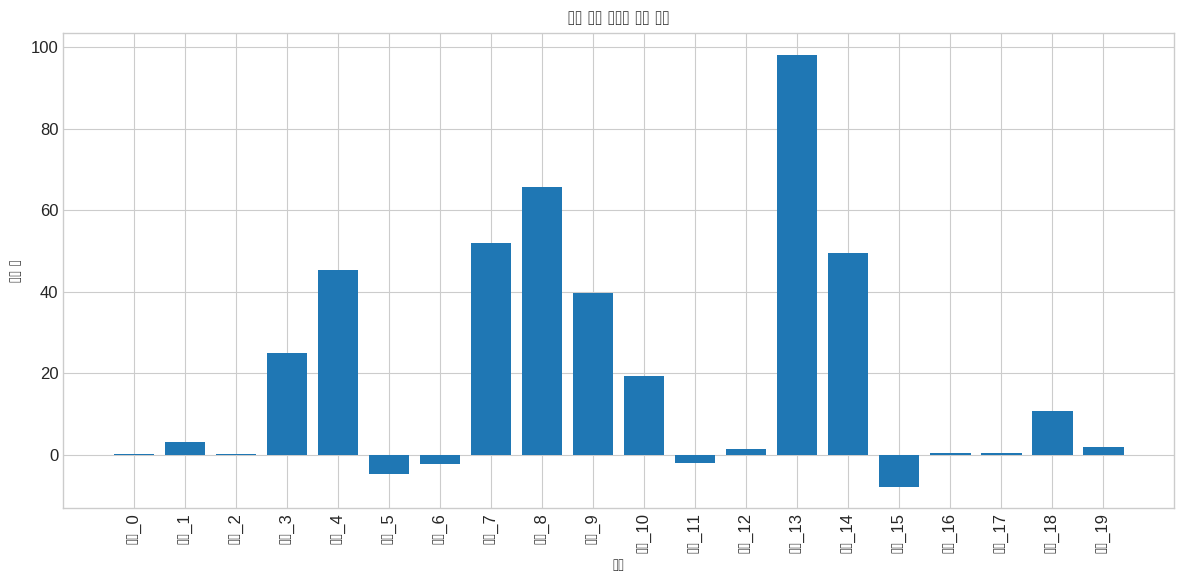

In [9]:
# 선형 회귀 계수 시각화
plt.figure(figsize=(12, 6))
plt.bar(X.columns, lr.coef_)
plt.title('선형 회귀 모델의 특성 계수')
plt.xlabel('특성')
plt.ylabel('계수 값')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Ridge 회귀 모델 학습 및 평가

Ridge 회귀는 L2 정규화를 사용하여 모든 계수의 제곱합을 최소화하는 방향으로 학습합니다. 이는 모든 특성의 영향을 줄이지만, 완전히 0으로 만들지는 않습니다.

In [10]:
# 다양한 알파 값에 대한 Ridge 회귀 모델 학습
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_models = {}
ridge_train_mse = []
ridge_test_mse = []
ridge_train_r2 = []
ridge_test_r2 = []
ridge_coefs = []

for alpha in alphas:
    # 모델 학습
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    ridge_models[alpha] = ridge

    # 예측 및 평가
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)

    # 평가 지표 저장
    ridge_train_mse.append(mean_squared_error(y_train, y_train_pred))
    ridge_test_mse.append(mean_squared_error(y_test, y_test_pred))
    ridge_train_r2.append(r2_score(y_train, y_train_pred))
    ridge_test_r2.append(r2_score(y_test, y_test_pred))
    ridge_coefs.append(ridge.coef_)

    print(f"Ridge 회귀 (alpha={alpha})")
    print(f"훈련 MSE: {ridge_train_mse[-1]:.2f}, 테스트 MSE: {ridge_test_mse[-1]:.2f}")
    print(f"훈련 R²: {ridge_train_r2[-1]:.4f}, 테스트 R²: {ridge_test_r2[-1]:.4f}")
    print("-" * 50)

Ridge 회귀 (alpha=0.01)
훈련 MSE: 426.15, 테스트 MSE: 390.86
훈련 R²: 0.9830, 테스트 R²: 0.9835
--------------------------------------------------
Ridge 회귀 (alpha=0.1)
훈련 MSE: 426.23, 테스트 MSE: 391.29
훈련 R²: 0.9830, 테스트 R²: 0.9835
--------------------------------------------------
Ridge 회귀 (alpha=1.0)
훈련 MSE: 429.16, 테스트 MSE: 392.25
훈련 R²: 0.9829, 테스트 R²: 0.9835
--------------------------------------------------
Ridge 회귀 (alpha=10.0)
훈련 MSE: 509.95, 테스트 MSE: 375.51
훈련 R²: 0.9797, 테스트 R²: 0.9842
--------------------------------------------------
Ridge 회귀 (alpha=100.0)
훈련 MSE: 3681.41, 테스트 MSE: 3118.04
훈련 R²: 0.8532, 테스트 R²: 0.8687
--------------------------------------------------


<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 50508 (\N{HANGUL SYLLABLE AL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-11-4b9dee08aa90>:22: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Liberation Sans.
  pl

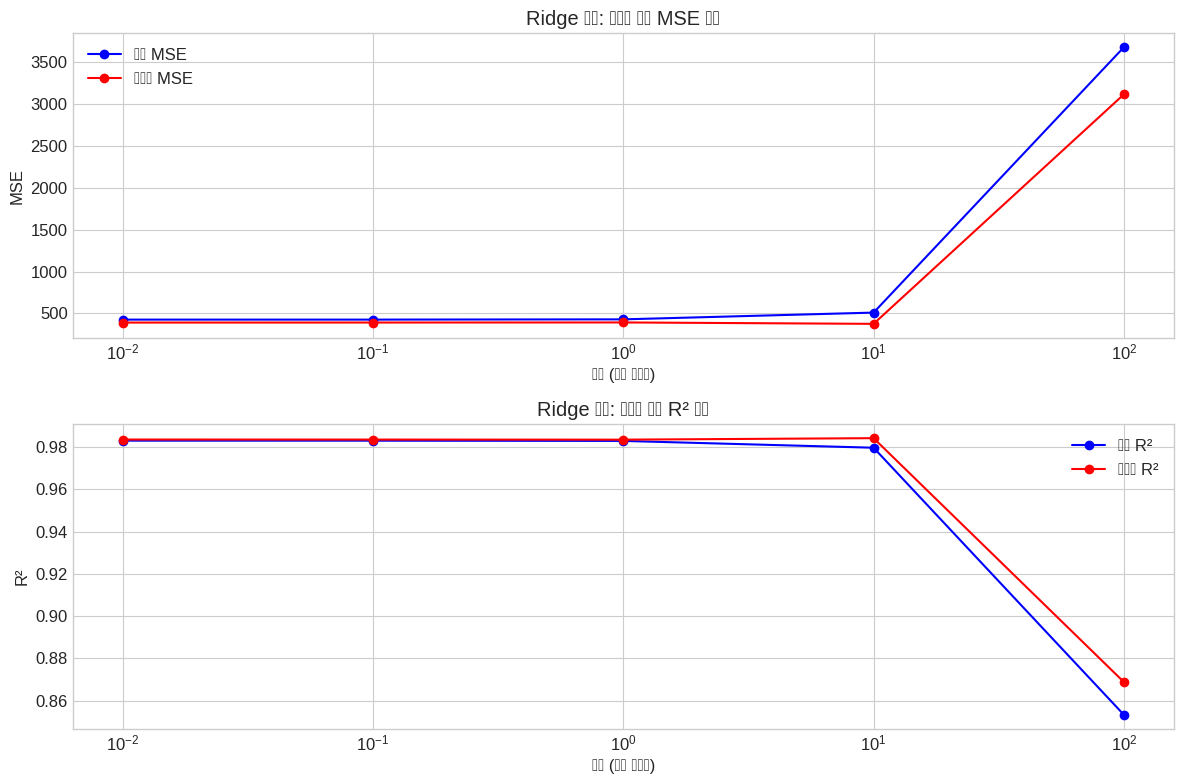

In [11]:
# Ridge 회귀의 알파 값에 따른 성능 변화 시각화
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.semilogx(alphas, ridge_train_mse, 'b-o', label='훈련 MSE')
plt.semilogx(alphas, ridge_test_mse, 'r-o', label='테스트 MSE')
plt.xlabel('알파 (로그 스케일)')
plt.ylabel('MSE')
plt.title('Ridge 회귀: 알파에 따른 MSE 변화')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(alphas, ridge_train_r2, 'b-o', label='훈련 R²')
plt.semilogx(alphas, ridge_test_r2, 'r-o', label='테스트 R²')
plt.xlabel('알파 (로그 스케일)')
plt.ylabel('R²')
plt.title('Ridge 회귀: 알파에 따른 R² 변화')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-12-59a0089c71bf>:11: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) Liberation Sa

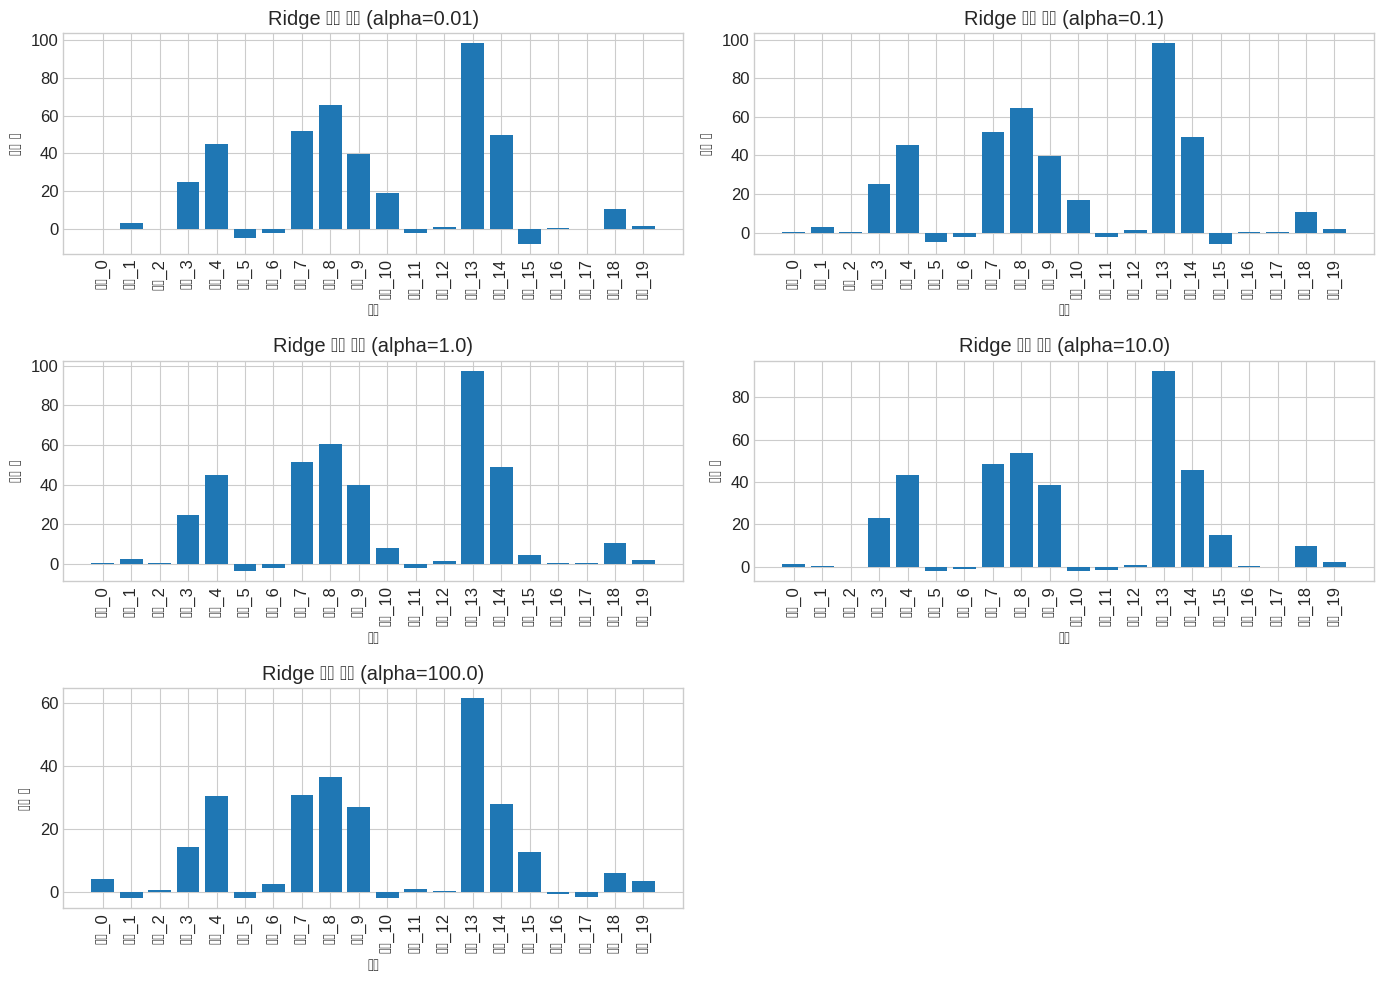

In [12]:
# Ridge 회귀의 알파 값에 따른 계수 변화 시각화
plt.figure(figsize=(14, 10))

for i, alpha in enumerate(alphas):
    plt.subplot(3, 2, i+1)
    plt.bar(X.columns, ridge_coefs[i])
    plt.title(f'Ridge 회귀 계수 (alpha={alpha})')
    plt.xlabel('특성')
    plt.ylabel('계수 값')
    plt.xticks(rotation=90)
    plt.tight_layout()

plt.tight_layout()
plt.show()

## 6. Lasso 회귀 모델 학습 및 평가

Lasso 회귀는 L1 정규화를 사용하여 계수의 절대값 합을 최소화하는 방향으로 학습합니다. 이는 중요하지 않은 특성의 계수를 정확히 0으로 만들어 특성 선택 효과를 가져옵니다.

In [13]:
# 다양한 알파 값에 대한 Lasso 회귀 모델 학습
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
lasso_models = {}
lasso_train_mse = []
lasso_test_mse = []
lasso_train_r2 = []
lasso_test_r2 = []
lasso_coefs = []
lasso_n_nonzero = []

for alpha in alphas:
    # 모델 학습
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    lasso_models[alpha] = lasso

    # 예측 및 평가
    y_train_pred = lasso.predict(X_train_scaled)
    y_test_pred = lasso.predict(X_test_scaled)

    # 평가 지표 저장
    lasso_train_mse.append(mean_squared_error(y_train, y_train_pred))
    lasso_test_mse.append(mean_squared_error(y_test, y_test_pred))
    lasso_train_r2.append(r2_score(y_train, y_train_pred))
    lasso_test_r2.append(r2_score(y_test, y_test_pred))
    lasso_coefs.append(lasso.coef_)
    lasso_n_nonzero.append(np.sum(lasso.coef_ != 0))

    print(f"Lasso 회귀 (alpha={alpha})")
    print(f"훈련 MSE: {lasso_train_mse[-1]:.2f}, 테스트 MSE: {lasso_test_mse[-1]:.2f}")
    print(f"훈련 R²: {lasso_train_r2[-1]:.4f}, 테스트 R²: {lasso_test_r2[-1]:.4f}")
    print(f"0이 아닌 계수 개수: {lasso_n_nonzero[-1]} / {X.shape[1]}")
    print("-" * 50)

Lasso 회귀 (alpha=0.0001)
훈련 MSE: 426.15, 테스트 MSE: 390.84
훈련 R²: 0.9830, 테스트 R²: 0.9835
0이 아닌 계수 개수: 20 / 20
--------------------------------------------------
Lasso 회귀 (alpha=0.001)
훈련 MSE: 426.15, 테스트 MSE: 391.17
훈련 R²: 0.9830, 테스트 R²: 0.9835
0이 아닌 계수 개수: 20 / 20
--------------------------------------------------
Lasso 회귀 (alpha=0.01)
훈련 MSE: 426.21, 테스트 MSE: 393.63
훈련 R²: 0.9830, 테스트 R²: 0.9834
0이 아닌 계수 개수: 20 / 20
--------------------------------------------------
Lasso 회귀 (alpha=0.1)
훈련 MSE: 427.43, 테스트 MSE: 399.63
훈련 R²: 0.9830, 테스트 R²: 0.9832
0이 아닌 계수 개수: 18 / 20
--------------------------------------------------
Lasso 회귀 (alpha=1.0)
훈련 MSE: 446.97, 테스트 MSE: 399.42
훈련 R²: 0.9822, 테스트 R²: 0.9832
0이 아닌 계수 개수: 13 / 20
--------------------------------------------------


<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 50508 (\N{HANGUL SYLLABLE AL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-14-1621c914f849>:22: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Liberation Sans.
  pl

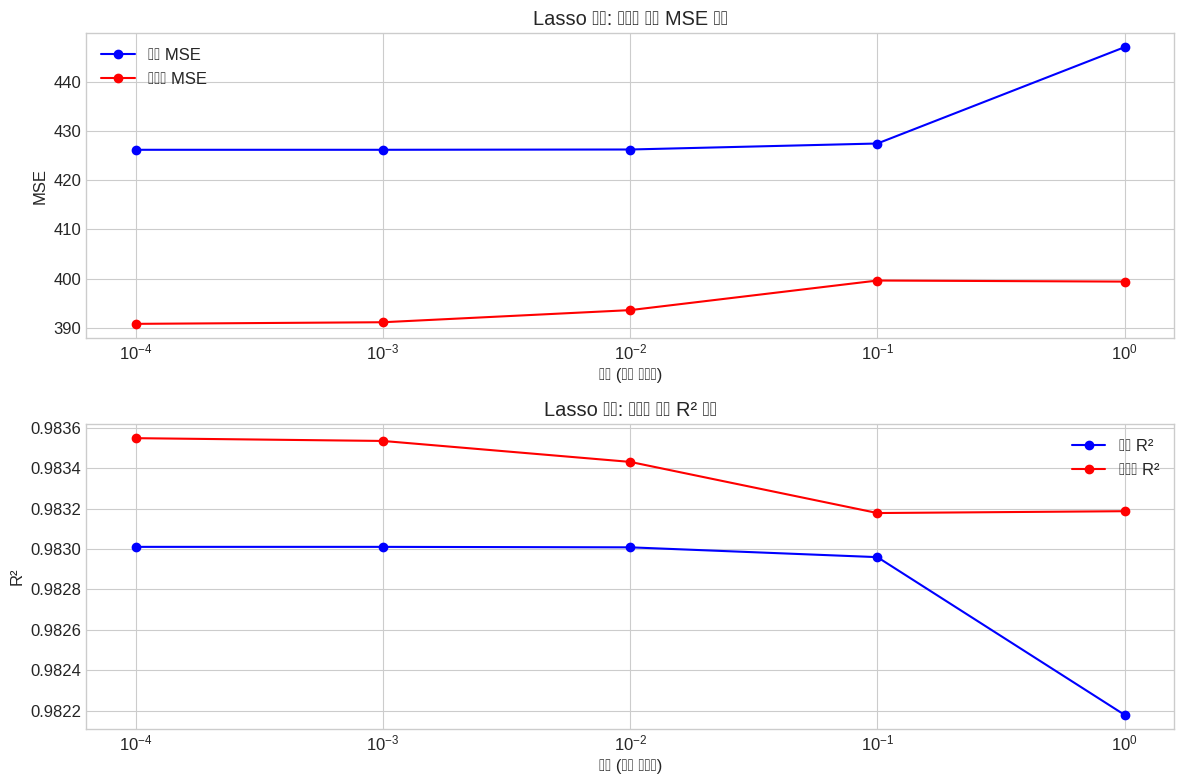

In [14]:
# Lasso 회귀의 알파 값에 따른 성능 변화 시각화
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.semilogx(alphas, lasso_train_mse, 'b-o', label='훈련 MSE')
plt.semilogx(alphas, lasso_test_mse, 'r-o', label='테스트 MSE')
plt.xlabel('알파 (로그 스케일)')
plt.ylabel('MSE')
plt.title('Lasso 회귀: 알파에 따른 MSE 변화')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(alphas, lasso_train_r2, 'b-o', label='훈련 R²')
plt.semilogx(alphas, lasso_test_r2, 'r-o', label='테스트 R²')
plt.xlabel('알파 (로그 스케일)')
plt.ylabel('R²')
plt.title('Lasso 회귀: 알파에 따른 R² 변화')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-15-c9a295f1b990>:11: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) Liberation Sa

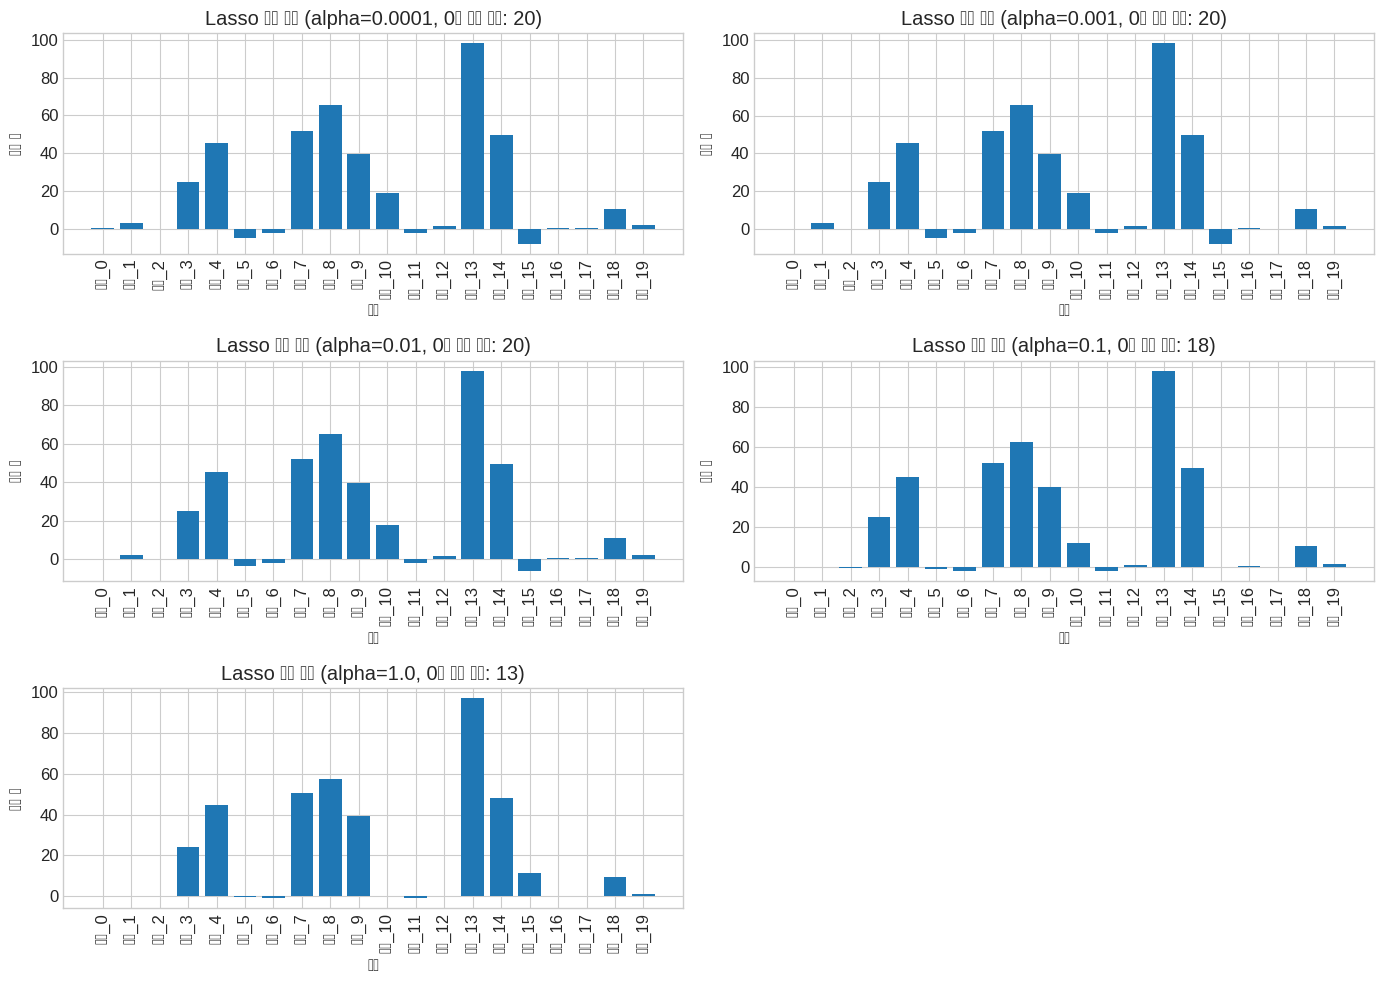

In [15]:
# Lasso 회귀의 알파 값에 따른 계수 변화 시각화
plt.figure(figsize=(14, 10))

for i, alpha in enumerate(alphas):
    plt.subplot(3, 2, i+1)
    plt.bar(X.columns, lasso_coefs[i])
    plt.title(f'Lasso 회귀 계수 (alpha={alpha}, 0이 아닌 계수: {lasso_n_nonzero[i]})')
    plt.xlabel('특성')
    plt.ylabel('계수 값')
    plt.xticks(rotation=90)
    plt.tight_layout()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


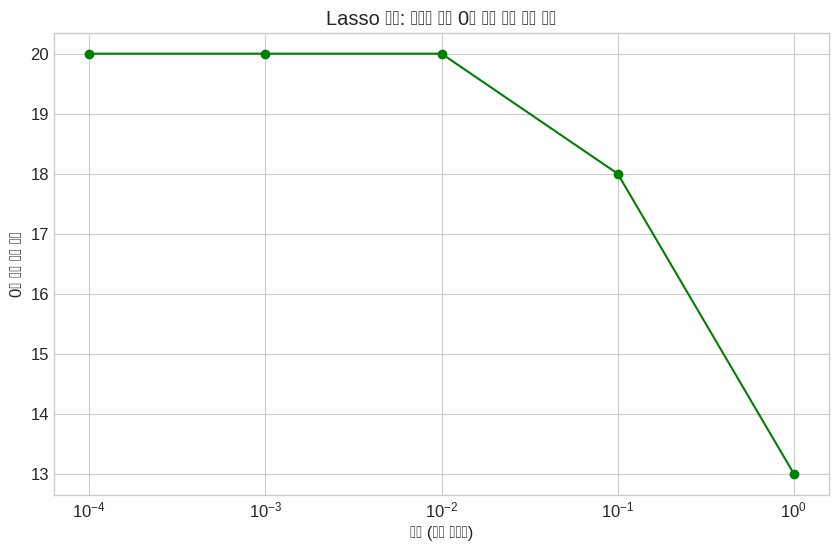

In [16]:
# 0이 아닌 계수 개수 시각화
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, lasso_n_nonzero, 'g-o')
plt.xlabel('알파 (로그 스케일)')
plt.ylabel('0이 아닌 계수 개수')
plt.title('Lasso 회귀: 알파에 따른 0이 아닌 계수 개수 변화')
plt.grid(True)
plt.show()

## 7. Ridge와 Lasso 회귀 비교

In [17]:
# 최적의 Ridge와 Lasso 모델 선택
best_ridge_idx = np.argmin(ridge_test_mse)
best_lasso_idx = np.argmin(lasso_test_mse)

best_ridge_alpha = alphas[best_ridge_idx]
best_lasso_alpha = alphas[best_lasso_idx]

print(f"최적의 Ridge 모델 (alpha={best_ridge_alpha})")
print(f"테스트 MSE: {ridge_test_mse[best_ridge_idx]:.2f}, 테스트 R²: {ridge_test_r2[best_ridge_idx]:.4f}")
print("\n")
print(f"최적의 Lasso 모델 (alpha={best_lasso_alpha})")
print(f"테스트 MSE: {lasso_test_mse[best_lasso_idx]:.2f}, 테스트 R²: {lasso_test_r2[best_lasso_idx]:.4f}")
print(f"0이 아닌 계수 개수: {lasso_n_nonzero[best_lasso_idx]} / {X.shape[1]}")

최적의 Ridge 모델 (alpha=0.1)
테스트 MSE: 375.51, 테스트 R²: 0.9842


최적의 Lasso 모델 (alpha=0.0001)
테스트 MSE: 390.84, 테스트 R²: 0.9835
0이 아닌 계수 개수: 20 / 20


<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-18-76da5a8c954b>:16: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Liberatio

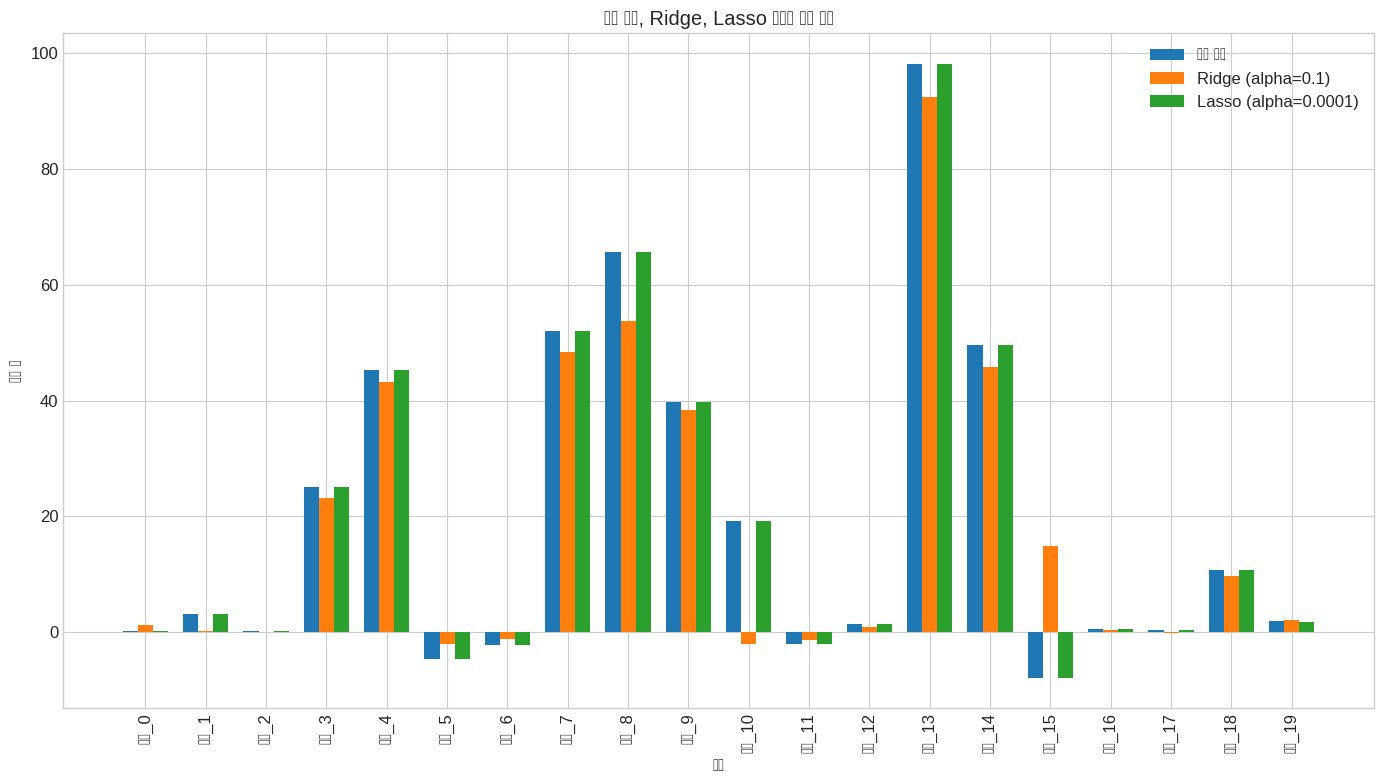

In [18]:
# 세 모델의 계수 비교 시각화
plt.figure(figsize=(14, 8))

width = 0.25
x = np.arange(len(X.columns))

plt.bar(x - width, lr.coef_, width, label='선형 회귀')
plt.bar(x, ridge_coefs[best_ridge_idx], width, label=f'Ridge (alpha={best_ridge_alpha})')
plt.bar(x + width, lasso_coefs[best_lasso_idx], width, label=f'Lasso (alpha={best_lasso_alpha})')

plt.xlabel('특성')
plt.ylabel('계수 값')
plt.title('선형 회귀, Ridge, Lasso 모델의 계수 비교')
plt.xticks(x, X.columns, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
<ipython-input-19-14c8d4a0d2f7>:32: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation 

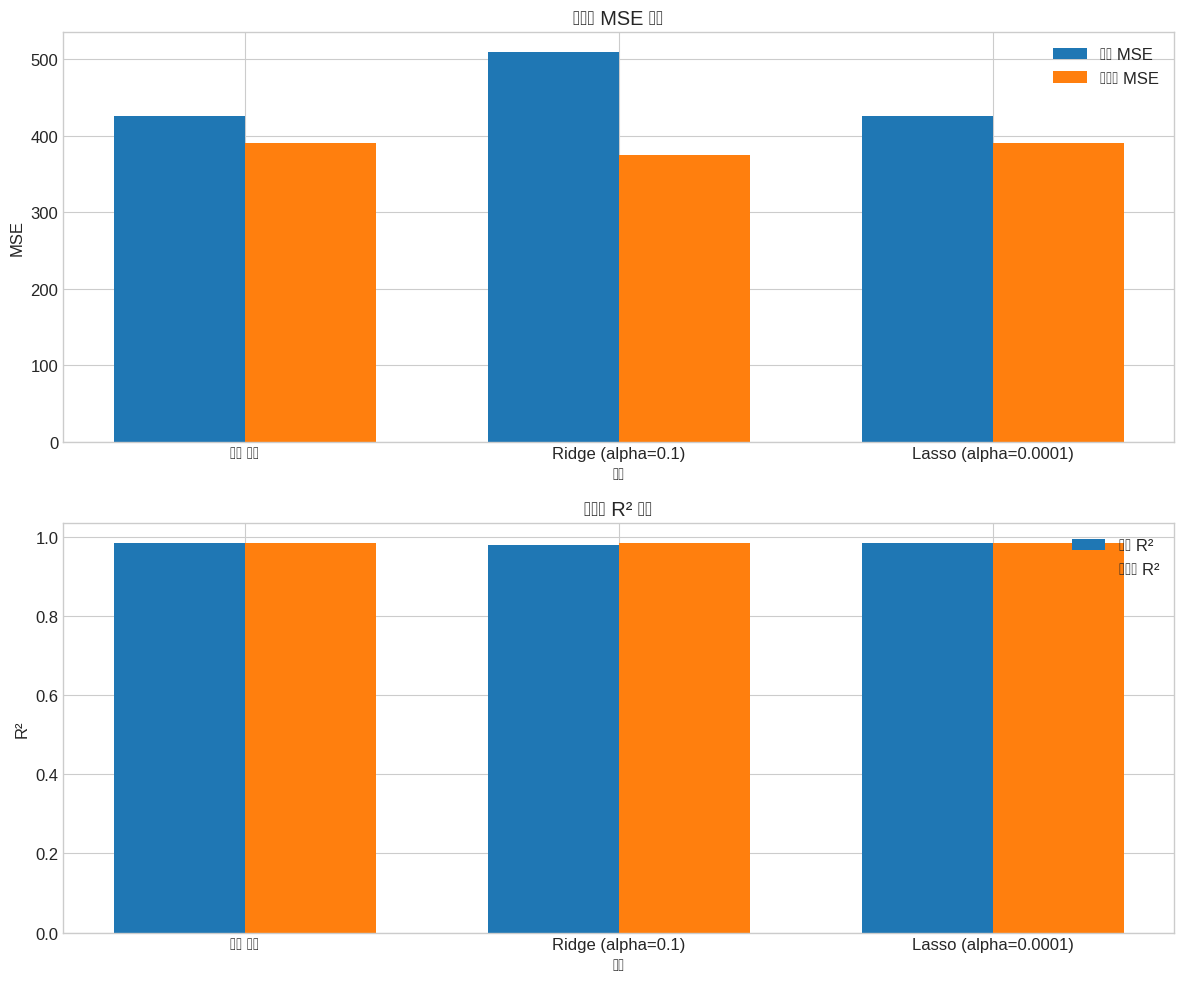

In [19]:
# 세 모델의 성능 비교
models = ['선형 회귀', f'Ridge (alpha={best_ridge_alpha})', f'Lasso (alpha={best_lasso_alpha})']
train_mse = [train_mse_lr, ridge_train_mse[best_ridge_idx], lasso_train_mse[best_lasso_idx]]
test_mse = [test_mse_lr, ridge_test_mse[best_ridge_idx], lasso_test_mse[best_lasso_idx]]
train_r2 = [train_r2_lr, ridge_train_r2[best_ridge_idx], lasso_train_r2[best_lasso_idx]]
test_r2 = [test_r2_lr, ridge_test_r2[best_ridge_idx], lasso_test_r2[best_lasso_idx]]

# MSE 비교
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, train_mse, width, label='훈련 MSE')
plt.bar(x + width/2, test_mse, width, label='테스트 MSE')
plt.xlabel('모델')
plt.ylabel('MSE')
plt.title('모델별 MSE 비교')
plt.xticks(x, models)
plt.legend()

# R² 비교
plt.subplot(2, 1, 2)
plt.bar(x - width/2, train_r2, width, label='훈련 R²')
plt.bar(x + width/2, test_r2, width, label='테스트 R²')
plt.xlabel('모델')
plt.ylabel('R²')
plt.title('모델별 R² 비교')
plt.xticks(x, models)
plt.legend()

plt.tight_layout()
plt.show()

## 8. 결론

이 실습에서는 선형 회귀 모델에 정규화를 적용하는 Ridge와 Lasso 회귀를 비교해보았습니다. 주요 결과는 다음과 같습니다:

1. **기본 선형 회귀**: 정규화가 없어 과적합 위험이 있으며, 다중 공선성이 있는 경우 계수가 불안정할 수 있습니다.

2. **Ridge 회귀**: L2 정규화를 사용하여 모든 계수를 축소하지만 0으로 만들지는 않습니다. 다중 공선성이 있는 경우 효과적입니다.

3. **Lasso 회귀**: L1 정규화를 사용하여 일부 계수를 정확히 0으로 만들어 특성 선택 효과를 가집니다. 중요한 특성만 남기고 싶을 때 유용합니다.

정규화 강도를 조절하는 알파 매개변수는 모델 성능에 큰 영향을 미치므로, 교차 검증을 통해 최적의 값을 찾는 것이 중요합니다. 일반적으로 Ridge는 모든 특성이 어느 정도 중요할 때, Lasso는 일부 특성만 중요할 때 더 효과적입니다.